In [3]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

### A4.19: Optimal vehicle speed scheduling

Minimize $$ \Sigma_{i=1}^n \Phi(s_i) \frac{d_i}{s_i} $$

such that 
$$
s \geq s_{min} \\
s \leq s_{max} \\
\tau = L(d/s) \\
\tau \geq \tau_{min} \\
\tau \leq \tau_{max}
$$
For the variables $s$ and $\tau$, where $L$ is the lower triangular matrix of ones.

We can make the substitution $t = d / s$, so we now have the perspective function

Minimize $$ \Sigma_{i=1}^n \Phi(\frac{d_i}{t_i}) t_i $$

such that 
$$
t \geq \frac{d}{s_{max}} \\
t \leq \frac{d}{s_{min}} \\
\tau = Lt \\
\tau \geq \tau_{min} \\
\tau \leq \tau_{max} \\
t > 0
$$
For the variable $t \in R^n$, where $L$ is the lower triangular matrix of ones.

In [4]:
n =   100
a =     1
b =     6
c =    10
d = np.array(
    [1.9501, 1.2311, 1.6068, 1.4860, 1.8913, 1.7621, 1.4565, 1.0185, 1.8214, 1.4447, 
     1.6154, 1.7919, 1.9218, 1.7382, 1.1763, 1.4057, 1.9355, 1.9169, 1.4103, 1.8936, 
     1.0579, 1.3529, 1.8132, 1.0099, 1.1389, 1.2028, 1.1987, 1.6038, 1.2722, 1.1988, 
     1.0153, 1.7468, 1.4451, 1.9318, 1.4660, 1.4186, 1.8462, 1.5252, 1.2026, 1.6721,
     1.8381, 1.0196, 1.6813, 1.3795, 1.8318, 1.5028, 1.7095, 1.4289, 1.3046, 1.1897, 
     1.1934, 1.6822, 1.3028, 1.5417, 1.1509, 1.6979, 1.3784, 1.8600, 1.8537, 1.5936, 
     1.4966, 1.8998, 1.8216, 1.6449, 1.8180, 1.6602, 1.3420, 1.2897, 1.3412, 1.5341, 
     1.7271, 1.3093, 1.8385, 1.5681, 1.3704, 1.7027, 1.5466, 1.4449, 1.6946, 1.6213, 
     1.7948, 1.9568, 1.5226, 1.8801, 1.1730, 1.9797, 1.2714, 1.2523, 1.8757, 1.7373, 
     1.1365, 1.0118, 1.8939, 1.1991, 1.2987, 1.6614, 1.2844, 1.4692, 1.0648, 1.9883])
smin = np.array(
    [0.7828, 0.6235, 0.7155, 0.5340, 0.6329, 0.4259, 0.7798, 0.9604, 0.7298, 0.8405, 0.4091, 
     0.5798, 0.9833, 0.8808, 0.6611, 0.7678, 0.9942, 0.2592, 0.8029, 0.2503, 0.6154, 0.5050,
     1.0744, 0.2150, 0.9680, 1.1708, 1.1901, 0.9889, 0.6387, 0.6983, 0.4140, 0.8435, 0.5200,
     1.1601, 0.9266, 0.6120, 0.9446, 0.4679, 0.6399, 1.1334, 0.8833, 0.4126, 1.0392, 0.8288,
     0.3338, 0.4071, 0.8072, 0.8299, 0.5705, 0.7751, 0.6514, 0.2439, 0.2272, 0.5127, 0.2129,
     0.5840, 0.8831, 0.2928, 0.2353, 0.8124, 0.8085, 0.2158, 0.2164, 0.3901, 0.7869, 0.2576,
     0.5676, 0.8315, 0.9176, 0.8927, 0.2841, 0.6544, 0.6418, 0.5533, 0.3536, 0.8756, 0.8992,
     0.9275, 0.6784, 0.7548, 0.3210, 0.6508, 0.9159, 1.0928, 0.4731, 0.4548, 1.0656, 0.4324,
     1.0049, 1.1084, 0.4319, 0.4393, 0.2498, 0.2784, 0.8408, 0.3909, 1.0439, 0.3739, 0.3708,
     1.1943])
smax = np.array(
    [1.9624, 1.6036, 1.6439, 1.5641, 1.7194, 1.9090, 1.3193, 1.3366, 1.9470, 2.8803, 2.5775, 
     1.4087, 1.6039, 2.9266, 1.4369, 2.3595, 3.2280, 1.8890, 2.8436, 0.5701, 1.1894, 2.4425, 
     2.2347, 2.2957, 2.7378, 2.8455, 2.1823, 1.6209, 1.2499, 1.3805, 1.5589, 2.8554, 1.8005, 
     3.0920, 2.1482, 1.8267, 2.1459, 1.5924, 2.7431, 1.4445, 1.7781, 0.8109, 2.7256, 2.4290, 
     2.5997, 1.8125, 1.9073, 1.5275, 2.1209, 2.5419, 1.7032, 0.5636, 1.3669, 2.3200, 2.1006, 
     2.7239, 2.8726, 1.3283, 1.7769, 2.5750, 1.4963, 2.3254, 1.6548, 1.9537, 1.5557, 1.6551, 
     2.7307, 1.8018, 2.5287, 1.9765, 1.8387, 2.3525, 1.7362, 1.6805, 1.9640, 2.8508, 1.9424, 
     2.0780, 2.1677, 2.1863, 2.0541, 1.9734, 2.7687, 2.3715, 1.1449, 2.1560, 3.3310, 2.3456, 
     2.7120, 2.3783, 0.9611, 2.0690, 1.2805, 0.8585, 2.2744, 2.3369, 2.6918, 2.6728, 2.5941, 
     1.6120])
tau_min = np.array(
    [1.0809, 2.7265, 3.5118, 5.3038, 5.4516, 7.1648, 9.2674, 12.1543, 14.4058, 16.6258,
     17.9214, 19.8242, 22.2333, 22.4849, 25.3213, 28.0691, 29.8751, 30.6358, 33.2561, 
     34.7963, 36.9943, 38.2610, 41.1451, 41.3613, 43.0215, 43.8974, 46.4713, 47.4786, 
     49.5192, 49.6795, 50.7495, 52.2444, 53.5477, 55.2351, 57.0850, 57.4250, 60.1198, 
     62.3834, 64.7568, 67.2016, 69.2116, 69.8143, 70.6335, 72.5122, 74.1228, 74.3013, 
     74.5682, 75.3821, 76.6093, 78.0315, 80.7584, 82.5472, 83.5340, 84.9686, 86.7601, 
     87.2445, 89.7329, 92.6013, 94.3879, 94.4742, 96.9105, 98.7409, 100.8453, 101.1219, 
     102.3966, 103.5233, 104.0218, 106.5212, 109.0372, 110.3920, 113.2618, 113.7033, 
     116.3131, 118.6214, 119.9539, 121.8157, 124.6708, 126.5908, 127.3328, 128.3909, 
     128.9545, 130.4264, 131.6542, 133.0448, 134.8776, 135.0912, 136.0340, 137.8591, 
     138.3842, 140.2473, 140.9852, 142.7472, 144.2654, 145.6597, 147.2840, 150.1110, 
     151.1363, 152.3417, 153.2647, 154.4994])
tau_max = np.array(
    [4.6528, 6.5147, 7.5178, 9.7478, 9.0641, 10.3891, 13.1540, 16.0878, 17.4352, 20.9539, 
     22.3695, 23.3875, 25.7569, 26.9019, 29.8890, 33.0415, 33.8218, 35.4414, 37.1583, 39.4054, 
     41.6520, 41.5935, 44.9329, 45.4028, 47.4577, 48.0358, 50.3929, 51.3692, 52.6947, 53.5665, 
     54.4821, 55.8495, 58.2514, 59.7541, 61.9845, 61.5409, 63.1482, 66.5758, 69.3892, 72.1558, 
     72.6555, 74.2216, 74.6777, 77.3780, 78.5495, 77.7574, 78.4675, 78.7265, 81.5470, 81.7429, 
     83.8565, 87.0579, 88.3237, 88.5409, 90.2625, 92.1100, 92.9949, 97.4829, 98.7916, 99.1695, 
     100.3291, 102.6510, 104.0075, 105.8242, 106.5207, 107.1619, 107.7716, 111.2568, 112.7815, 
     113.5394, 116.6615, 116.8022, 120.4465, 121.8652, 123.9981, 125.0498, 129.2106, 130.3409, 
     131.9796, 131.4842, 133.1503, 135.3247, 135.2318, 137.8225, 138.0808, 138.2218, 139.5026, 
     142.7253, 141.5105, 143.7757, 145.9842, 146.1712, 148.2622, 149.2407, 151.6295, 155.0270, 
     155.6694, 156.6739, 156.5266, 157.6903])

In [8]:
t = cp.Variable(n, pos=True)
L = np.tril(np.ones((n, n)))

obj419 = cp.Minimize(
    cp.sum(a * (d**2) * cp.inv_pos(t) + b * d + c * t)
)

constr419 = [
    t >= d / smax,
    t <= d / smin,
    L @ t >= tau_min,
    L @ t <= tau_max
]

prob = cp.Problem(obj419, constr419)
prob.solve()

c:\Users\kyler\EE364A\.venv\Lib\site-packages\cvxpy\expressions\expression.py:750: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 1 times so far.

  warnings.warn(msg, UserWarning)


np.float64(17657.76689113336)

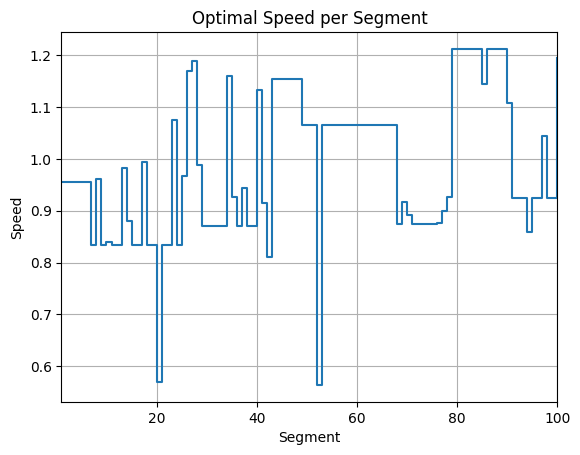

In [9]:
s_opt = d / t.value

segments = np.arange(1, len(s_opt) + 1)

plt.figure()

plt.step(segments, s_opt, where='post')
plt.xlabel("Segment")
plt.ylabel("Speed")
plt.title("Optimal Speed per Segment")

plt.xlim(1, len(s_opt))
plt.grid(True)

plt.show()

### A10.3: Infeasible start Newton method for LP centering problem

In [ ]:
def infeasible_newton(A, b, c, x0, max_iters=50, stop_crit=1e-6, alpha=0.25, beta=0.5):

    m, n = A.shape
    x = x0.copy()
    nu = np.zeros(m)

    residual_history = []

    for k in range(max_iters):

        # calculate newton step
        r_dual = c - 1/x + A.T @ nu
        r_pri = A @ x - b
        r = np.hstack((r_dual, r_pri))

        residual_history.append(np.linalg.norm(r))

        if np.linalg.norm(r) < stop_crit:
            break

        H_inv = x**2

        AHinv = A * H_inv
        S = AHinv @ A.T

        rhs = r_pri - AHinv @ r_dual

        d_nu = np.linalg.solve(S, rhs)

        d_x = -H_inv * (r_dual + A.T @ d_nu)

        # line search
        t = 1

        while np.any(x + t*d_x <= 0):
            t *= beta

        while True:
            x_new = x + t*d_x
            nu_new = nu + t*d_nu

            r_dual_new = c - 1/x_new + A.T @ nu_new
            r_pri_new = A @ x_new - b
            r_new = np.hstack((r_dual_new, r_pri_new))

            if np.linalg.norm(r_new) <= (1 - alpha*t)*np.linalg.norm(r):
                break

            t *= beta

        x += t*d_x
        nu += t*d_nu

    return x, nu, residual_history

In [36]:
def run_experiments():

    m = 10
    n = 60

    plt.figure()

    for trial in range(5):

        A = np.random.randn(m, n)
        p = np.random.rand(n) + 1
        b = A @ p
        c = np.random.randn(n)

        x0 = np.random.rand(n) + 0.5

        _, _, res_hist = infeasible_newton(A, b, c, x0)

        plt.semilogy(res_hist, label=f"trial {trial}")

    plt.xlabel("iteration k")
    plt.ylabel("||r(x,ν)||₂")
    plt.title("Residual norm vs iteration (Infeasible Newton)")
    plt.legend()
    plt.grid(True)

    plt.show()

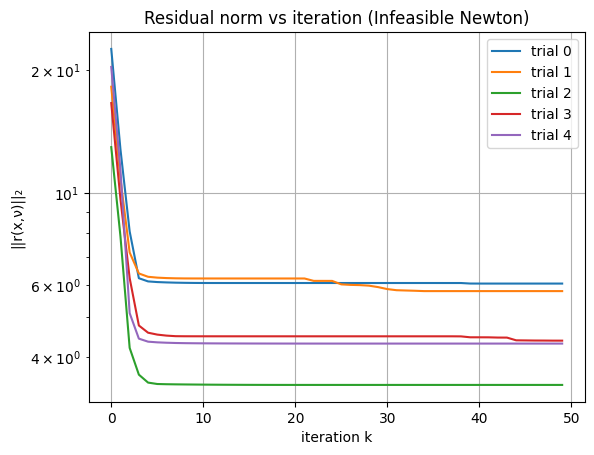

In [39]:
run_experiments()

### A13.1: Time to solve one or multiple sets of linear equations

a) One hundred microseconds  
b) One hundred microseconds  

### A14.3: Optimal amplifier gains

Since amplifier gains are all positive, we can rewrite the objective as  
maximize
$$ \frac{S_n}{N_n} $$
such that 
$$
s_i = a_i s_{i-1} \\
s_i \leq M_i \\
a_1 a_2 ... a_n = A_{tot} \\
a_i \leq A_i^{max} \\
N_0 = 0 \\
N_i = a_i (N_{i-1}^2 + \alpha_i^2)^{1/2}
$$
The only one of these constraints that is not DGP is the last one, which we can rewrite as 
$$
N_i^2 = a_i^2N_{i-1}^2 + a_i^2\alpha_i^2
$$
Now, we can make the relaxation 
$$
N_i^2 \geq a_i^2N_{i-1}^2 + a_i^2\alpha_i^2
$$
as this overestimates the noise per step, and the inequality at the optimal point will always be tight. We now have a posynomial inequality constraint, making this problem DGP.

In [14]:
A = 10000
alpha = [10e-5, 10e-2, 10e-2, 10e-2]
M = [0.1, 5, 10, 10]
A_max = [40, 40, 40, 20]
n = 4

In [15]:
eps = 1e-6

S = cp.Variable(n, pos=True)
N = cp.Variable(n, pos=True)
a = cp.Variable(n, pos=True)

obj143 = cp.Maximize(S[-1] / N[-1])
constr143 = [
    S <= M,
    cp.prod(a) == A,
    a <= A_max,
    N[0] == eps
]
for i in range(1, n):
    constr143 += [S[i] == a[i] * S[i-1]]
    constr143 += [N[i]**2 >= a[i]**2 * N[i-1]**2 + a[i]**2 * alpha[i]**2]

prob143 = cp.Problem(obj143, constr143)
prob143.solve(gp=True)
print(f"optimal signal to noise ratio: {prob143.value:.2f}")
print(f"optimal amplifier values: {a.value}")

optimal signal to noise ratio: 0.40
optimal amplifier values: [39.99999997 39.99997983  6.24980258  1.00003209]


### A15.8: Optimizing rates and time slot fractions